Thuật toán svm hay randomforest không biết chữ nên cần biến đồi thành số vector hóa

🚀 === SO SÁNH & LƯU TẤT CẢ MÔ HÌNH === 🚀


📦 Đang xử lý: Naive_Bayes...
              precision    recall  f1-score   support

       World       0.89      0.88      0.89      5956
      Sports       0.93      0.97      0.95      6058
    Business       0.86      0.82      0.84      5911
    Sci/Tech       0.86      0.85      0.86      6075

    accuracy                           0.88     24000
   macro avg       0.88      0.88      0.88     24000
weighted avg       0.88      0.88      0.88     24000



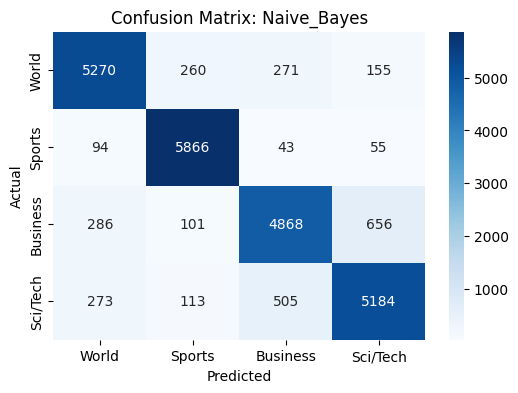


📦 Đang xử lý: Logistic_Regression...
              precision    recall  f1-score   support

       World       0.91      0.89      0.90      5956
      Sports       0.94      0.97      0.95      6058
    Business       0.87      0.86      0.87      5911
    Sci/Tech       0.88      0.87      0.88      6075

    accuracy                           0.90     24000
   macro avg       0.90      0.90      0.90     24000
weighted avg       0.90      0.90      0.90     24000



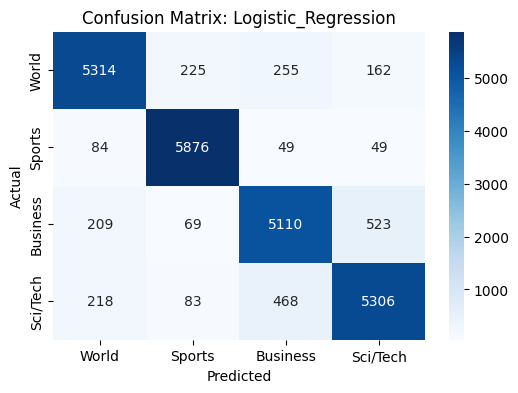


📦 Đang xử lý: LinearSVC...
              precision    recall  f1-score   support

       World       0.91      0.89      0.90      5956
      Sports       0.94      0.97      0.96      6058
    Business       0.86      0.87      0.87      5911
    Sci/Tech       0.88      0.87      0.87      6075

    accuracy                           0.90     24000
   macro avg       0.90      0.90      0.90     24000
weighted avg       0.90      0.90      0.90     24000



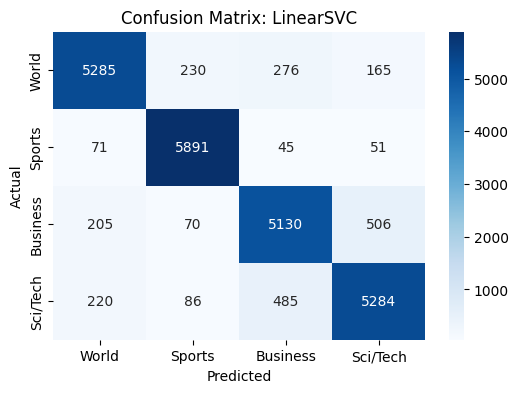


THUẬT TOÁN           | ACCURACY   | TIME      
--------------------------------------------------
Naive_Bayes          | 0.8828     | 0.02s
Logistic_Regression  | 0.9002     | 2.66s
LinearSVC            | 0.8996     | 3.76s
🏆 MÔ HÌNH TỐT NHẤT: Logistic_Regression (Đã lưu vào best_classifier.pkl)


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
import os
import time

# --- CẤU HÌNH ---
DATA_PATH = "../data/raw/train.csv"
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)
MAPPING = ["", "World", "Sports", "Business", "Sci/Tech"] # Dành cho AG News

print("🚀 === SO SÁNH & LƯU TẤT CẢ MÔ HÌNH === 🚀\n")

# 1. Đọc dữ liệu
df = pd.read_csv(DATA_PATH).fillna("")
df['text'] = (df['Title'] + ' ' + df['Description'])
vectorizer = TfidfVectorizer(max_features=3000) 
X = vectorizer.fit_transform(df['text'])
y = df['Class_Index']

# Lưu vectorizer dùng chung cho tất cả các model sau này
joblib.dump(vectorizer, os.path.join(MODEL_DIR, "tfidf_vectorizer_baseline.pkl"))

# 3. Chia Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Danh sách thuật toán
models_to_test = {
    'Naive_Bayes': MultinomialNB(),
    'Logistic_Regression': LogisticRegression(max_iter=2000, random_state=42),
    'LinearSVC': LinearSVC(max_iter=4000, random_state=42, dual='auto')
}

best_accuracy = 0
summary_results = []

# Huấn luyện và Đánh giá
for name, model in models_to_test.items():
    print(f"\n📦 Đang xử lý: {name}...")
    
    start_time = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start_time
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    # Lưu TỪNG mô hình vào file riêng
    model_filename = f"{name.lower()}.pkl"
    joblib.dump(model, os.path.join(MODEL_DIR, model_filename))
    
    # Lưu kết quả tổng quan
    summary_results.append({'Model': name, 'Accuracy': acc, 'Time': elapsed})
    
    if acc > best_accuracy:
        best_accuracy = acc
        joblib.dump(model, os.path.join(MODEL_DIR, "best_classifier_baseline.pkl"))
        best_name = name

    # In Metrics chi tiết (Precision, Recall, F1)
    print(classification_report(y_test, y_pred, target_names=MAPPING[1:]))

    # Vẽ Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=MAPPING[1:], yticklabels=MAPPING[1:])
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# 5. Bảng tổng kết cuối cùng
print("\n" + "="*50)
print(f"{'THUẬT TOÁN':<20} | {'ACCURACY':<10} | {'TIME':<10}")
print("-"*50)
for res in summary_results:
    print(f"{res['Model']:<20} | {res['Accuracy']:.4f}     | {res['Time']:.2f}s")
print("="*50)
print(f"🏆 MÔ HÌNH TỐT NHẤT: {best_name} (Đã lưu vào best_classifier.pkl)")

🚀 === SO SÁNH & LƯU TẤT CẢ MÔ HÌNH === 🚀


📦 Đang xử lý: Naive_Bayes_Baseline...
              precision    recall  f1-score   support

       World       0.88      0.88      0.88      5956
      Sports       0.92      0.96      0.94      6058
    Business       0.84      0.81      0.83      5911
    Sci/Tech       0.84      0.83      0.84      6075

    accuracy                           0.87     24000
   macro avg       0.87      0.87      0.87     24000
weighted avg       0.87      0.87      0.87     24000



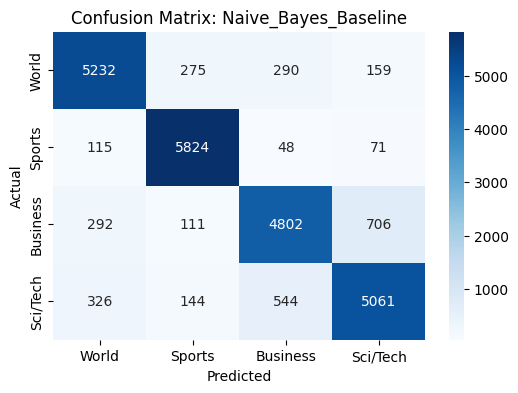


📦 Đang xử lý: Logistic_Regression_Baseline...
              precision    recall  f1-score   support

       World       0.91      0.89      0.90      5956
      Sports       0.94      0.97      0.95      6058
    Business       0.86      0.86      0.86      5911
    Sci/Tech       0.87      0.87      0.87      6075

    accuracy                           0.90     24000
   macro avg       0.90      0.90      0.90     24000
weighted avg       0.90      0.90      0.90     24000



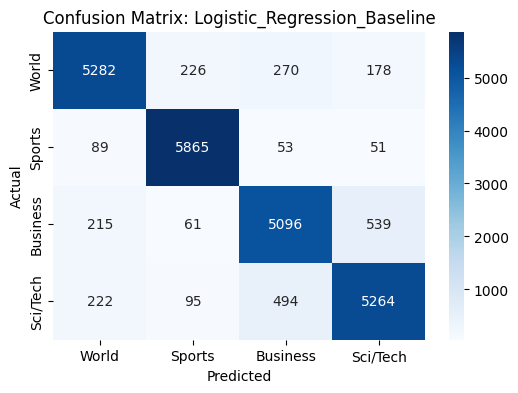


📦 Đang xử lý: LinearSVC_Baseline...
              precision    recall  f1-score   support

       World       0.92      0.88      0.90      5956
      Sports       0.94      0.97      0.96      6058
    Business       0.86      0.86      0.86      5911
    Sci/Tech       0.88      0.87      0.87      6075

    accuracy                           0.90     24000
   macro avg       0.90      0.90      0.90     24000
weighted avg       0.90      0.90      0.90     24000



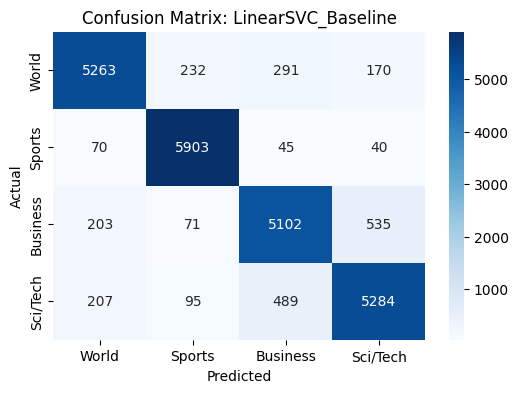


THUẬT TOÁN           | ACCURACY   | TIME      
--------------------------------------------------
Naive_Bayes_Baseline | 0.8716     | 0.04s
Logistic_Regression_Baseline | 0.8961     | 5.31s
LinearSVC_Baseline   | 0.8980     | 5.72s
🏆 MÔ HÌNH TỐT NHẤT: LinearSVC_Baseline (Đã lưu vào best_classifier.pkl)


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
import os
import time

# --- CẤU HÌNH ---
DATA_PATH = "../data/processed/df_enriched.csv"
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)
MAPPING = ["", "World", "Sports", "Business", "Sci/Tech"] # Dành cho AG News

print("🚀 === SO SÁNH & LƯU TẤT CẢ MÔ HÌNH === 🚀\n")

# 1. Đọc dữ liệu
df_enriched = pd.read_csv(DATA_PATH).fillna("")

# 2. Tiền xử lý & Vector hóa
df_enriched['combined_text'] = (df_enriched['text'] + " " + 
                                df_enriched['wordnet_features'] + " " + 
                                df_enriched['dbpedia_features'])

vectorizer = TfidfVectorizer(max_features=3000) 
X = vectorizer.fit_transform(df_enriched['combined_text'])
y = df_enriched['label']

# Lưu vectorizer dùng chung cho tất cả các model sau này
joblib.dump(vectorizer, os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl"))

# 3. Chia Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Danh sách thuật toán
models_to_test = {
    'Naive_Bayes_Baseline': MultinomialNB(),
    'Logistic_Regression_Baseline': LogisticRegression(max_iter=2000, random_state=42),
    'LinearSVC_Baseline': LinearSVC(max_iter=4000, random_state=42, dual='auto')
}

best_accuracy = 0
summary_results = []

# Huấn luyện và Đánh giá
for name, model in models_to_test.items():
    print(f"\n📦 Đang xử lý: {name}...")
    
    start_time = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start_time
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    # Lưu TỪNG mô hình vào file riêng
    model_filename = f"{name.lower()}.pkl"
    joblib.dump(model, os.path.join(MODEL_DIR, model_filename))
    
    # Lưu kết quả tổng quan
    summary_results.append({'Model': name, 'Accuracy': acc, 'Time': elapsed})
    
    if acc > best_accuracy:
        best_accuracy = acc
        joblib.dump(model, os.path.join(MODEL_DIR, "best_classifier.pkl"))
        best_name = name

    # In Metrics chi tiết (Precision, Recall, F1)
    print(classification_report(y_test, y_pred, target_names=MAPPING[1:]))

    # Vẽ Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=MAPPING[1:], yticklabels=MAPPING[1:])
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# 5. Bảng tổng kết cuối cùng
print("\n" + "="*50)
print(f"{'THUẬT TOÁN':<20} | {'ACCURACY':<10} | {'TIME':<10}")
print("-"*50)
for res in summary_results:
    print(f"{res['Model']:<20} | {res['Accuracy']:.4f}     | {res['Time']:.2f}s")
print("="*50)
print(f"🏆 MÔ HÌNH TỐT NHẤT: {best_name} (Đã lưu vào best_classifier.pkl)")

In [48]:
import pandas as pd
import numpy as np
import os
import time
import joblib
import re

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# ==============================
# CONFIG
# ==============================
CLEAN_PATH = "../data/processed/df_clean.csv"
ENRICH_PATH = "../data/processed/df_enriched.csv"
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE = 42

print("🚀 === CLEAN vs ENRICHED EXPERIMENT ===\n")

# ==============================
# 1. LOAD DATA
# ==============================
df_clean = pd.read_csv(CLEAN_PATH).fillna("")
df_enrich = pd.read_csv(ENRICH_PATH).fillna("")

# đảm bảo cùng thứ tự
assert len(df_clean) == len(df_enrich)

y = df_clean['label']

# ==============================
# 2. BUILD TEXT
# ==============================

# CLEAN
X_clean = df_clean['text']

# 🔥 ENRICHED (QUAN TRỌNG)
def clean_noise(text):
    # loại bớt WordNet noise
    text = text.lower()
    text = re.sub(r"\b(unit|structure|entity|object|thing)\b", "", text)
    return text

def build_enriched(row):
    base = row['text']

    wordnet = clean_noise(str(row.get('wordnet_features', "")))
    dbpedia = str(row.get('dbpedia_features', ""))

    # ⚠️ trick quan trọng: giảm weight WordNet
    enriched = f"{base} {dbpedia} {wordnet} {wordnet}"

    return enriched

X_enrich = df_enrich.apply(build_enriched, axis=1)

# ==============================
# 3. SPLIT (CHUNG)
# ==============================
X_train_c, X_test_c, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train_e, X_test_e, _, _ = train_test_split(
    X_enrich, y, test_size=0.2, random_state=RANDOM_STATE
)

# ==============================
# 4. TRAIN FUNCTION
# ==============================
def train_and_eval(X_train, X_test, y_train, y_test, name):
    print(f"\n📦 Training: {name}")

    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=5000,          # tăng capacity
            ngram_range=(1,2),
            min_df=3,                  # 🔥 giảm noise
            max_df=0.9,
            sublinear_tf=True
        )),
        ('clf', LinearSVC())
    ])

    start = time.time()
    pipeline.fit(X_train, y_train)
    elapsed = time.time() - start

    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n=== {name} REPORT ===")
    print(classification_report(y_test, y_pred))
    print(f"{name} Accuracy: {acc:.4f}")
    print(f"{name} Time: {elapsed:.2f}s")

    return {
        "name": name,
        "accuracy": acc,
        "pipeline": pipeline,
        "y_pred": y_pred
    }

# ==============================
# 5. RUN
# ==============================
res_clean = train_and_eval(X_train_c, X_test_c, y_train, y_test, "CLEAN")
res_enrich = train_and_eval(X_train_e, X_test_e, y_train, y_test, "ENRICHED")

# ==============================
# 6. COMPARE
# ==============================
print("\n" + "="*50)
print("📊 COMPARISON")
print("="*50)

print(f"CLEAN     : {res_clean['accuracy']:.4f}")
print(f"ENRICHED  : {res_enrich['accuracy']:.4f}")

gain = res_enrich['accuracy'] - res_clean['accuracy']
print(f"\n🔥 Gain: {gain:+.4f}")

# ==============================
# 7. SAVE
# ==============================
joblib.dump(res_clean['pipeline'], os.path.join(MODEL_DIR, "clean_pipeline.pkl"))
joblib.dump(res_enrich['pipeline'], os.path.join(MODEL_DIR, "enriched_pipeline.pkl"))

best = res_enrich if res_enrich['accuracy'] > res_clean['accuracy'] else res_clean
joblib.dump(best['pipeline'], os.path.join(MODEL_DIR, "best_pipeline.pkl"))

print(f"\n🏆 Best: {best['name']}")

# ==============================
# 8. DEBUG FEATURE (QUAN TRỌNG)
# ==============================
def show_top_features(pipeline, n=10):
    clf = pipeline.named_steps['clf']
    tfidf = pipeline.named_steps['tfidf']
    feature_names = np.array(tfidf.get_feature_names_out())

    for i, cls in enumerate(clf.classes_):
        top = np.argsort(clf.coef_[i])[-n:]
        print(f"\nClass {cls}:")
        print(feature_names[top])

print("\n🔍 TOP FEATURES - CLEAN")
show_top_features(res_clean['pipeline'])

print("\n🔍 TOP FEATURES - ENRICHED")
show_top_features(res_enrich['pipeline'])

🚀 === CLEAN vs ENRICHED EXPERIMENT ===


📦 Training: CLEAN

=== CLEAN REPORT ===
              precision    recall  f1-score   support

           1       0.91      0.90      0.90      5956
           2       0.94      0.97      0.96      6058
           3       0.87      0.87      0.87      5911
           4       0.88      0.87      0.88      6075

    accuracy                           0.90     24000
   macro avg       0.90      0.90      0.90     24000
weighted avg       0.90      0.90      0.90     24000

CLEAN Accuracy: 0.9029
CLEAN Time: 14.36s

📦 Training: ENRICHED

=== ENRICHED REPORT ===
              precision    recall  f1-score   support

           1       0.91      0.89      0.90      5956
           2       0.94      0.97      0.95      6058
           3       0.86      0.86      0.86      5911
           4       0.88      0.87      0.87      6075

    accuracy                           0.90     24000
   macro avg       0.90      0.90      0.90     24000
weighted avg   